<a href="https://colab.research.google.com/github/Reeva-17/Customer-Churn-Prediction/blob/main/notebooks/07_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Customer Churn Prediction
## Random Forest Classifier

In [ ]:
!git clone https://github.com/Reeva-17/Customer-Churn-Prediction.git

Cloning into 'Customer-Churn-Prediction'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 108 (delta 51), reused 11 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (108/108), 1.21 MiB | 6.48 MiB/s, done.
Resolving deltas: 100% (51/51), done.


In [ ]:
%cd Customer-Churn-Prediction/notebooks

/content/Customer-Churn-Prediction/notebooks


In [ ]:
!pwd

/content/Customer-Churn-Prediction/notebooks


In [ ]:
# Import Libraries

import os
import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [ ]:
# Load Dataset

base_url = "https://raw.githubusercontent.com/Reeva-17/Customer-Churn-Prediction/main/data/processed/"

X_train = pd.read_csv(base_url + "X_train.csv")
X_test = pd.read_csv(base_url + "X_test.csv")
y_train = pd.read_csv(base_url + "y_train.csv").squeeze()
y_test = pd.read_csv(base_url + "y_test.csv").squeeze()

print("Train Shape :", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape : (5625, 30)
Test Shape : (1407, 30)


In [ ]:
# Baseline Model

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Baseline Results

y_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_pred))

Accuracy : 0.7882018479033405
Precision : 0.6233766233766234
Recall : 0.5133689839572193
F1 Score : 0.5630498533724341
ROC AUC : 0.7005373477385323


In [ ]:
# Tune Parameters

param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,15,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4],

    "max_features":["sqrt","log2"]

}

In [ ]:
# Grid Search

grid = GridSearchCV(

    estimator=rf,

    param_grid=param_grid,

    scoring="f1",

    cv=5,

    n_jobs=-1,

    verbose=2

)

grid.fit(X_train,y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1', verbose=2)

In [ ]:
# Best Model

best_model = grid.best_estimator_

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
0.5799322896329068


In [ ]:
# Test Predictions

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc = roc_auc_score(y_test,y_pred)

print("Accuracy :",accuracy)
print("Precision :",precision)
print("Recall :",recall)
print("F1 :",f1)
print("ROC :",roc)

Accuracy : 0.7903340440653873
Precision : 0.6321070234113713
Recall : 0.5053475935828877
F1 : 0.5616641901931649
ROC : 0.6994308151844739


In [ ]:
# Classification Report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



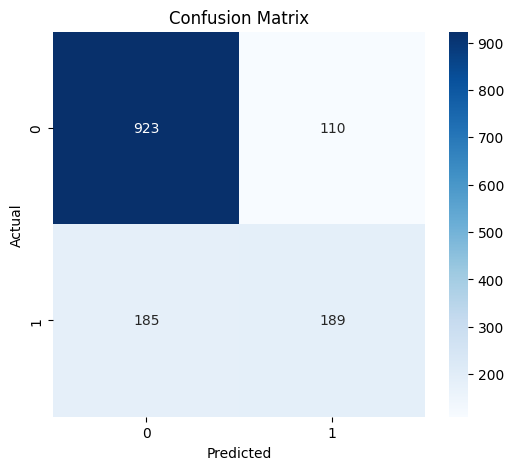

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

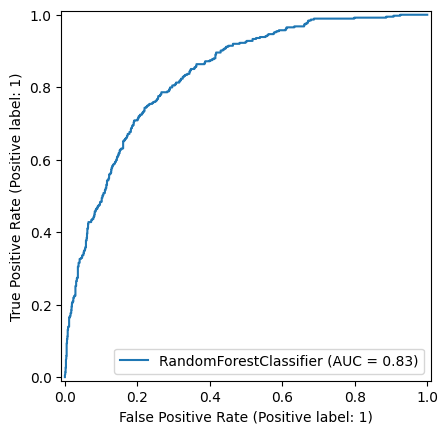

In [ ]:
# ROC Curve

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.show()

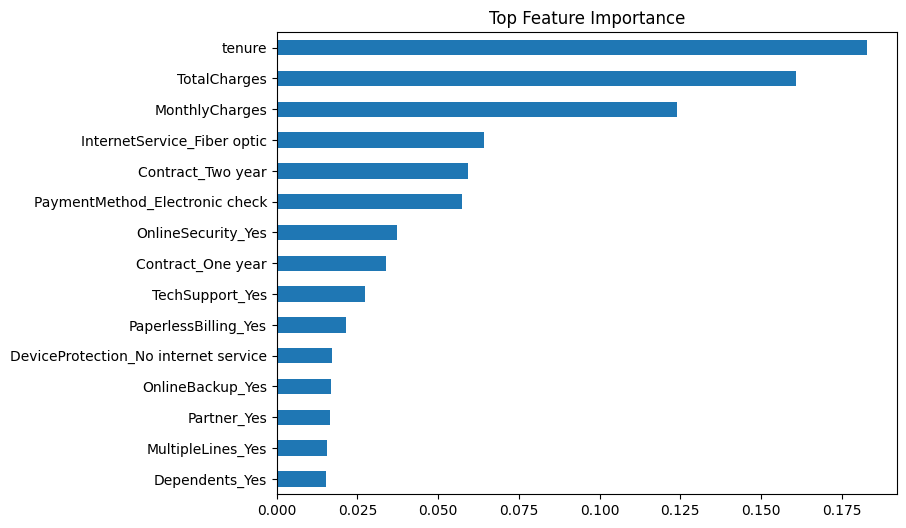

In [ ]:
# Feature Importance

importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,6))

importance.head(15).plot(kind="barh")

plt.title("Top Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# Check Overfitting

train_pred = best_model.predict(X_train)

train_accuracy = accuracy_score(y_train,train_pred)
train_precision = precision_score(y_train,train_pred)
train_recall = recall_score(y_train,train_pred)
train_f1 = f1_score(y_train,train_pred)

test_accuracy = accuracy_score(y_test,y_pred)
test_precision = precision_score(y_test,y_pred)
test_recall = recall_score(y_test,y_pred)
test_f1 = f1_score(y_test,y_pred)

comparison = pd.DataFrame({

"Metric":["Accuracy","Precision","Recall","F1 Score"],

"Train":[
train_accuracy,
train_precision,
train_recall,
train_f1
],

"Test":[
test_accuracy,
test_precision,
test_recall,
test_f1
]

})

comparison["Difference"]=abs(comparison["Train"]-comparison["Test"])

comparison

,Metric,Train,Test,Difference
0,Accuracy,0.868089,0.790334,0.077755
1,Precision,0.822622,0.632107,0.190515
2,Recall,0.642140,0.505348,0.136793
3,F1 Score,0.721262,0.561664,0.159598


In [ ]:
# Save model

import joblib

joblib.dump(
    best_model,
    "../models/random_forest.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [ ]:
# Check current directory

!pwd

/content


In [ ]:
# List current folder

!ls

sample_data


In [ ]:
# Check parent folder

!ls ..

bin	 datalab  home	  lib32   media  proc		    root  srv  tools
boot	 dev	  kaggle  lib64   mnt	 python-apt	    run   sys  usr
content  etc	  lib	  libx32  opt	 python-apt.tar.xz  sbin  tmp  var


In [ ]:
# Verify model

!ls ../models

decision_tree.pkl  logistic_regression.pkl  random_forest.pkl  svm_model.pkl


In [ ]:
from google.colab import files

files.download("../models/random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>